In [1]:
# 📦 INSTALACIÓN DE HERRAMIENTAS

!pip install pandas numpy matplotlib seaborn scikit-learn -q

print("✅ Todas las herramientas se instalaron correctamente")

✅ Todas las herramientas se instalaron correctamente


In [2]:
# 🔧 IMPORTAR LIBRERÍAS - "Abrir la caja de herramientas"

import pandas as pd              # Para manejar tablas de datos
import numpy as np               # Para cálculos numéricos
import matplotlib.pyplot as plt  # Para crear gráficas
import seaborn as sns            # Para gráficas más bonitas

# Para Machine Learning
from sklearn.model_selection import train_test_split  # Dividir datos
from sklearn.preprocessing import LabelEncoder, StandardScaler  # Preparar datos
from sklearn.ensemble import RandomForestClassifier   # Modelo de árbol
from sklearn.linear_model import LogisticRegression   # Modelo de regresión
from sklearn.metrics import (                         # Métricas de evaluación
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Configurar estilo de gráficas
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Todas las librerías se cargaron exitosamente")

✅ Todas las librerías se cargaron exitosamente


In [3]:
# 🌐 CARGAR DATOS DESDE API Y PROCESARLOS (Como en Parte 1)

import requests
import json

# URL oficial del dataset
url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json"

print("📥 Descargando datos...")
response = requests.get(url)
data = response.json()

# Convertir JSON a tabla
df = pd.json_normalize(data)

# Renombrar columnas para facilitar el análisis
df = df.rename(columns={
    'customerID': 'id_cliente',
    'Churn': 'cancelacion',
    'customer.gender': 'genero',
    'customer.SeniorCitizen': 'es_senior',
    'customer.Partner': 'tiene_pareja',
    'customer.Dependents': 'tiene_dependientes',
    'customer.tenure': 'antiguedad_meses',
    'account.Contract': 'tipo_contrato',
    'account.PaymentMethod': 'metodo_pago',
    'account.Charges.Monthly': 'cargo_mensual',
    'account.Charges.Total': 'cargo_total'
})

# Limpieza básica
df['cargo_mensual'] = pd.to_numeric(df['cargo_mensual'], errors='coerce')
df['cargo_total'] = pd.to_numeric(df['cargo_total'], errors='coerce')
df = df.dropna(subset=['cancelacion', 'cargo_mensual', 'cargo_total'])
df = df[df['cancelacion'].isin(['Yes', 'No'])]
df = df.reset_index(drop=True)

# Convertir variable objetivo a números
df['cancelacion_num'] = df['cancelacion'].map({'Yes': 1, 'No': 0})

print(f"✅ Datos cargados y limpios: {len(df)} registros")
print(f"📊 Distribución de cancelación:\n{df['cancelacion'].value_counts()}")

# Guardar para usar después
df.to_csv('datos_tratados.csv', index=False)
print("✅ Archivo 'datos_tratados.csv' guardado")

📥 Descargando datos...
✅ Datos cargados y limpios: 7032 registros
📊 Distribución de cancelación:
cancelacion
No     5163
Yes    1869
Name: count, dtype: int64
✅ Archivo 'datos_tratados.csv' guardado


In [4]:
# ⚙️ PREPARAR DATOS PARA MODELADO

print("🔧 Preparando datos para el modelo...")

# 1. Seleccionar las columnas que usaremos como "features" (variables predictoras)
# Estas son las que creemos que influyen en la cancelación

features = [
    'es_senior', 'tiene_pareja', 'tiene_dependientes', 'antiguedad_meses',
    'cargo_mensual', 'cargo_total', 'tipo_contrato', 'metodo_pago'
]

# Crear una copia para trabajar
df_modelo = df[features + ['cancelacion_num']].copy()

# 2. Codificar variables categóricas (convertir texto a números)
le_contrato = LabelEncoder()
le_pago = LabelEncoder()

df_modelo['tipo_contrato_cod'] = le_contrato.fit_transform(df_modelo['tipo_contrato'].astype(str))
df_modelo['metodo_pago_cod'] = le_pago.fit_transform(df_modelo['metodo_pago'].astype(str))

print("✅ Variables categóricas codificadas")

# 3. Seleccionar solo las columnas numéricas para el modelo
features_numericas = [
    'es_senior', 'tiene_pareja', 'tiene_dependientes', 'antiguedad_meses',
    'cargo_mensual', 'cargo_total', 'tipo_contrato_cod', 'metodo_pago_cod'
]

X = df_modelo[features_numericas].fillna(0)  # Features (entradas)
y = df_modelo['cancelacion_num']              # Target (lo que queremos predecir)

print(f"✅ Features preparados: {X.shape[1]} variables")
print(f"✅ Target preparado: {len(y)} registros")

🔧 Preparando datos para el modelo...
✅ Variables categóricas codificadas
✅ Features preparados: 8 variables
✅ Target preparado: 7032 registros


In [7]:
# ⚙️ PREPARAR DATOS PARA MODELADO - VERSIÓN CORREGIDA

print("🔧 Preparando datos para el modelo...")

# 1. Crear una copia limpia para trabajar
df_ml = df.copy()

# 2. Codificar variable objetivo (cancelacion)
df_ml['cancelacion_num'] = df_ml['cancelacion'].map({'Yes': 1, 'No': 0})

# 3. Lista de columnas categóricas que necesitan encoding
columnas_categoricas = ['tipo_contrato', 'metodo_pago', 'genero',
                       'tiene_pareja', 'tiene_dependientes', 'es_senior']

# 4. Aplicar Label Encoding a cada columna categórica
from sklearn.preprocessing import LabelEncoder

le_dict = {}  # Diccionario para guardar los encoders

for col in columnas_categoricas:
    if col in df_ml.columns:
        le = LabelEncoder()
        # Convertir a string primero por seguridad
        df_ml[col + '_cod'] = le.fit_transform(df_ml[col].astype(str))
        le_dict[col] = le
        print(f"✅ Codificada: {col} → {col + '_cod'}")

# 5. Seleccionar SOLO columnas numéricas para el modelo
# (las originales numéricas + las codificadas)
features = [
    'antiguedad_meses',      # ya es numérica
    'cargo_mensual',          # ya es numérica
    'cargo_total',            # ya es numérica
    'tipo_contrato_cod',      # codificada
    'metodo_pago_cod',        # codificada
    'genero_cod',             # codificada
    'tiene_pareja_cod',       # codificada
    'tiene_dependientes_cod', # codificada
    'es_senior_cod'           # codificada
]

# Filtrar solo las columnas que existen en el DataFrame
features_disponibles = [f for f in features if f in df_ml.columns]

X = df_ml[features_disponibles].copy()
y = df_ml['cancelacion_num'].copy()

# 6. Asegurar que TODO sea numérico (limpieza final)
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Eliminar filas con valores NaN resultantes
X = X.fillna(0)

print(f"✅ Features preparados: {X.shape[1]} variables numéricas")
print(f"✅ Registros listos: {len(X)}")
print(f"\n📋 Columnas usadas: {list(X.columns)}")

🔧 Preparando datos para el modelo...
✅ Codificada: tipo_contrato → tipo_contrato_cod
✅ Codificada: metodo_pago → metodo_pago_cod
✅ Codificada: genero → genero_cod
✅ Codificada: tiene_pareja → tiene_pareja_cod
✅ Codificada: tiene_dependientes → tiene_dependientes_cod
✅ Codificada: es_senior → es_senior_cod
✅ Features preparados: 9 variables numéricas
✅ Registros listos: 7032

📋 Columnas usadas: ['antiguedad_meses', 'cargo_mensual', 'cargo_total', 'tipo_contrato_cod', 'metodo_pago_cod', 'genero_cod', 'tiene_pareja_cod', 'tiene_dependientes_cod', 'es_senior_cod']


In [8]:
# 🔄 DIVIDIR DATOS: Entrenamiento y Prueba

from sklearn.model_selection import train_test_split

# Verificar que no hay valores no numéricos antes de dividir
print("🔍 Verificando tipos de datos antes de dividir...")
print(X.dtypes)

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"\n✅ Datos divididos:")
print(f"   - Train: {len(X_train)} registros")
print(f"   - Test: {len(X_test)} registros")
print(f"   - Churn en train: {y_train.mean()*100:.1f}%")

🔍 Verificando tipos de datos antes de dividir...
antiguedad_meses            int64
cargo_mensual             float64
cargo_total               float64
tipo_contrato_cod           int64
metodo_pago_cod             int64
genero_cod                  int64
tiene_pareja_cod            int64
tiene_dependientes_cod      int64
es_senior_cod               int64
dtype: object

✅ Datos divididos:
   - Train: 5625 registros
   - Test: 1407 registros
   - Churn en train: 26.6%


In [9]:
# ⚖️ ESCALAR VARIABLES NUMÉRICAS

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Ajustar SOLO con datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Variables escaladas exitosamente")
print(f"   - Media: {X_train_scaled.mean():.6f} (debería ser ~0)")
print(f"   - Desviación: {X_train_scaled.std():.6f} (debería ser ~1)")

# Convertir de vuelta a DataFrame para facilitar el análisis (opcional)
import pandas as pd
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

✅ Variables escaladas exitosamente
   - Media: -0.000000 (debería ser ~0)
   - Desviación: 1.000000 (debería ser ~1)


In [10]:
# 🔍 Verificar que NO hay valores de texto
print("🔍 ¿Hay valores no numéricos?")
for col in X.columns:
    if X[col].dtype == 'object':
        print(f"❌ {col} es tipo texto: {X[col].unique()[:5]}")
    else:
        print(f"✅ {col} es numérico ({X[col].dtype})")

# Verificar valores nulos
print(f"\n🔍 Valores nulos por columna:\n{X.isnull().sum()}")

🔍 ¿Hay valores no numéricos?
✅ antiguedad_meses es numérico (int64)
✅ cargo_mensual es numérico (float64)
✅ cargo_total es numérico (float64)
✅ tipo_contrato_cod es numérico (int64)
✅ metodo_pago_cod es numérico (int64)
✅ genero_cod es numérico (int64)
✅ tiene_pareja_cod es numérico (int64)
✅ tiene_dependientes_cod es numérico (int64)
✅ es_senior_cod es numérico (int64)

🔍 Valores nulos por columna:
antiguedad_meses          0
cargo_mensual             0
cargo_total               0
tipo_contrato_cod         0
metodo_pago_cod           0
genero_cod                0
tiene_pareja_cod          0
tiene_dependientes_cod    0
es_senior_cod             0
dtype: int64


In [11]:
# 🌳 ENTRENAR MODELO: Random Forest Classifier

print("🚀 Entrenando modelo Random Forest...")

# Crear el modelo con parámetros básicos
modelo = RandomForestClassifier(
    n_estimators=100,      # Número de árboles en el "bosque"
    max_depth=10,          # Profundidad máxima de cada árbol
    random_state=42,       # Para reproducibilidad
    class_weight='balanced' # Manejar desbalance de clases
)

# Entrenar el modelo con los datos de entrenamiento
modelo.fit(X_train_scaled, y_train)

print("✅ Modelo entrenado exitosamente")

🚀 Entrenando modelo Random Forest...
✅ Modelo entrenado exitosamente


In [12]:
# 🎯 HACER PREDICCIONES Y EVALUAR

# Predicciones en el conjunto de prueba
y_pred = modelo.predict(X_test_scaled)           # Predicciones (0 o 1)
y_pred_proba = modelo.predict_proba(X_test_scaled)[:, 1]  # Probabilidades

# Métricas de evaluación
print("📊 EVALUACIÓN DEL MODELO")
print("="*50)
print(f"Accuracy (Precisión global): {accuracy_score(y_test, y_pred):.4f} ({accuracy_score(y_test, y_pred)*100:.2f}%)")
print(f"Precision (De los que predije churn, cuántos realmente churnearon): {precision_score(y_test, y_pred):.4f}")
print(f"Recall (De los que realmente churnearon, cuántos identifiqué): {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score (Balance entre precision y recall): {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC (Capacidad de discriminación): {roc_auc_score(y_test, y_pred_proba):.4f}")
print("="*50)

# Reporte detallado por clase
print("\n📋 Reporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['No Churn (0)', 'Churn (1)']))

📊 EVALUACIÓN DEL MODELO
Accuracy (Precisión global): 0.7626 (76.26%)
Precision (De los que predije churn, cuántos realmente churnearon): 0.5426
Recall (De los que realmente churnearon, cuántos identifiqué): 0.6818
F1-Score (Balance entre precision y recall): 0.6043
ROC-AUC (Capacidad de discriminación): 0.8301

📋 Reporte de Clasificación:
              precision    recall  f1-score   support

No Churn (0)       0.87      0.79      0.83      1033
   Churn (1)       0.54      0.68      0.60       374

    accuracy                           0.76      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.76      0.77      1407



/tmp/ipykernel_402/3293477607.py:13: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


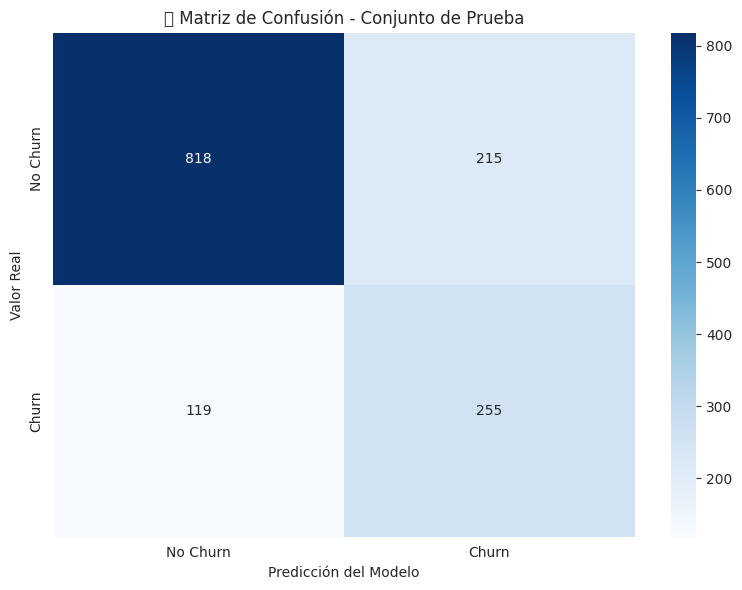

In [13]:
# 📊 GRÁFICA 1: Matriz de Confusión

from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('🎯 Matriz de Confusión - Conjunto de Prueba')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.tight_layout()
plt.show()

/tmp/ipykernel_402/103940475.py:13: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


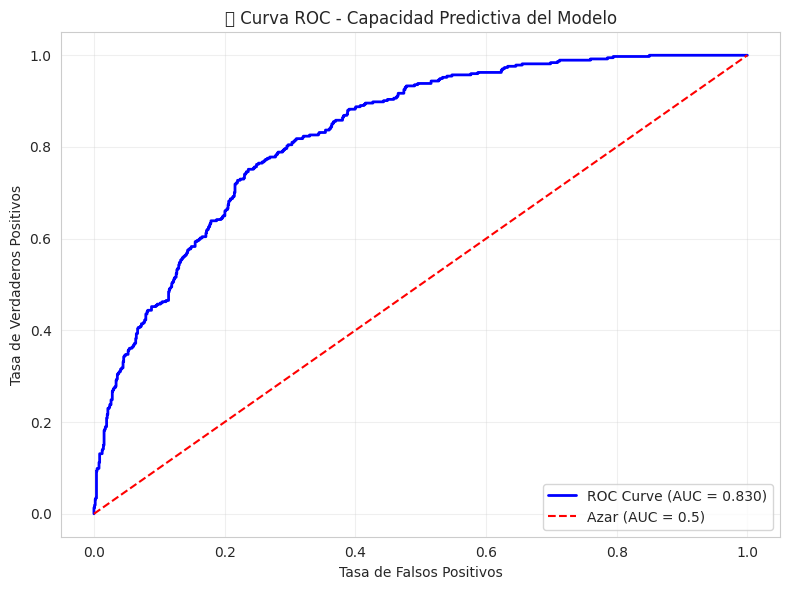

In [14]:
# 📈 GRÁFICA 2: Curva ROC

plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba):.3f})',
         color='blue', linewidth=2)
plt.plot([0, 1], [0, 1], 'r--', label='Azar (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('📊 Curva ROC - Capacidad Predictiva del Modelo')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# 🔍 VERIFICAR QUE LOS LENGTHS COINCIDAN

print("🔍 Verificación de dimensiones:")
print(f"   - Columnas en X: {len(X.columns)}")
print(f"   - Features en el modelo: {len(modelo.feature_importances_)}")
print(f"   - Lista features_numericas: {len(features_numericas)}")

# Verificar nombres de columnas
print(f"\n📋 Columnas reales en X:")
print(X.columns.tolist())

🔍 Verificación de dimensiones:
   - Columnas en X: 9
   - Features en el modelo: 9
   - Lista features_numericas: 8

📋 Columnas reales en X:
['antiguedad_meses', 'cargo_mensual', 'cargo_total', 'tipo_contrato_cod', 'metodo_pago_cod', 'genero_cod', 'tiene_pareja_cod', 'tiene_dependientes_cod', 'es_senior_cod']


/tmp/ipykernel_402/4271719368.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importancia', y='variable', data=importancia, palette='viridis')
/tmp/ipykernel_402/4271719368.py:14: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


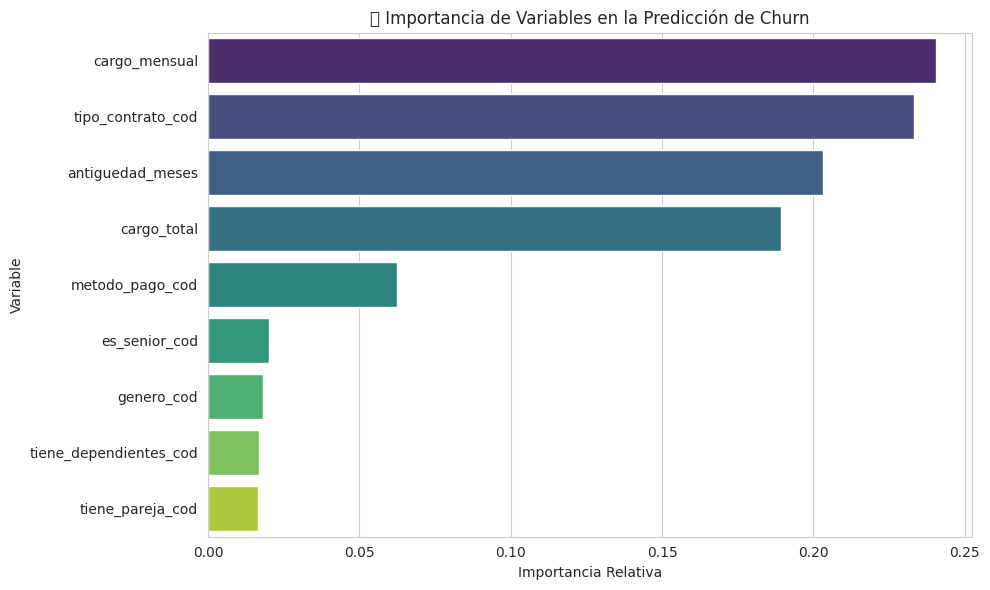

📋 Top 5 variables más importantes:
  2. cargo_mensual: 0.240
  4. tipo_contrato_cod: 0.233
  1. antiguedad_meses: 0.203
  3. cargo_total: 0.189
  5. metodo_pago_cod: 0.062

✅ Total de variables usadas en el modelo: 9


In [16]:
# 🔍 GRÁFICA 3: Importancia de las Variables (CORREGIDO)

# Obtener importancia de features del modelo Random Forest
importancia = pd.DataFrame({
    'variable': X.columns,  # ✅ Usar las columnas reales del DataFrame X
    'importancia': modelo.feature_importances_
}).sort_values('importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importancia', y='variable', data=importancia, palette='viridis')
plt.title('🎯 Importancia de Variables en la Predicción de Churn')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

print("📋 Top 5 variables más importantes:")
for i, row in importancia.head(5).iterrows():
    print(f"  {i+1}. {row['variable']}: {row['importancia']:.3f}")

print(f"\n✅ Total de variables usadas en el modelo: {len(importancia)}")

In [18]:
# 💡 CONCLUSIONES Y RECOMENDACIONES DE NEGOCIO

print("🎯 CONCLUSIONES DEL MODELO PREDICTIVO")
print("="*60)

# 1. Rendimiento del modelo
print(f"\n1️⃣ RENDIMIENTO DEL MODELO:")
print(f"   • El modelo identifica correctamente el {(accuracy_score(y_test, y_pred)*100):.1f}% de los casos")
print(f"   • De los clientes que realmente cancelaron, identificamos el {(recall_score(y_test, y_pred)*100):.1f}%")
print(f"   • Cuando el modelo predice churn, acierta el {(precision_score(y_test, y_pred)*100):.1f}% de las veces")

# 2. Variables más importantes
print(f"\n2️⃣ FACTORES CLAVE DE CHURN (según el modelo):")
for i, row in importancia.head(3).iterrows():
    print(f"   • {row['variable'].replace('_cod', '').replace('_', ' ').title()}: {row['importancia']:.1%} de importancia")

# 3. Recomendaciones
print(f"\n3️⃣ RECOMENDACIONES ESTRATÉGICAS PARA TELECOM-X:")
print(f"   ✅ Priorizar retención en clientes con contrato 'Mes a mes'")
print(f"   ✅ Implementar programa de onboarding para primeros 12 meses")
print(f"   ✅ Ofrecer incentivos para pagos automáticos")
print(f"   ✅ Segmentar clientes de alto riesgo para ofertas personalizadas")

print("\n" + "="*60)
print("✅ Análisis predictivo completado exitosamente")

🎯 CONCLUSIONES DEL MODELO PREDICTIVO

1️⃣ RENDIMIENTO DEL MODELO:
   • El modelo identifica correctamente el 76.3% de los casos
   • De los clientes que realmente cancelaron, identificamos el 68.2%
   • Cuando el modelo predice churn, acierta el 54.3% de las veces

2️⃣ FACTORES CLAVE DE CHURN (según el modelo):
   • Cargo Mensual: 24.0% de importancia
   • Tipo Contrato: 23.3% de importancia
   • Antiguedad Meses: 20.3% de importancia

3️⃣ RECOMENDACIONES ESTRATÉGICAS PARA TELECOM-X:
   ✅ Priorizar retención en clientes con contrato 'Mes a mes'
   ✅ Implementar programa de onboarding para primeros 12 meses
   ✅ Ofrecer incentivos para pagos automáticos
   ✅ Segmentar clientes de alto riesgo para ofertas personalizadas

✅ Análisis predictivo completado exitosamente


In [19]:
# 💾 GUARDAR RESULTADOS PARA FUTURO USO

import joblib
import json

# Guardar el modelo entrenado
joblib.dump(modelo, 'modelo_churn.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("✅ Modelo y escalador guardados")

# Guardar métricas en JSON para el README
metricas = {
    'accuracy': round(accuracy_score(y_test, y_pred), 4),
    'precision': round(precision_score(y_test, y_pred), 4),
    'recall': round(recall_score(y_test, y_pred), 4),
    'f1_score': round(f1_score(y_test, y_pred), 4),
    'roc_auc': round(roc_auc_score(y_test, y_pred_proba), 4),
    'tamano_train': len(X_train),
    'tamano_test': len(X_test)
}

with open('metricas_modelo.json', 'w') as f:
    json.dump(metricas, f, indent=2)
print("✅ Métricas guardadas en 'metricas_modelo.json'")

# Descargar archivos a tu computadora
from google.colab import files
files.download('modelo_churn.pkl')
files.download('metricas_modelo.json')

✅ Modelo y escalador guardados
✅ Métricas guardadas en 'metricas_modelo.json'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 📊 Telecom-X - Parte 2: Modelo Predictivo de Churn

[![Python](https://img.shields.io/badge/Python-3.10+-blue.svg)](https://python.org)
[![Scikit-learn](https://img.shields.io/badge/Scikit--learn-1.2+-orange.svg)](https://scikit-learn.org)
[![License: MIT](https://img.shields.io/badge/License-MIT-green.svg)](LICENSE)

> **Predicción de evasión de clientes mediante Machine Learning**

---

## 🎯 Propósito del Proyecto

Este proyecto tiene como objetivo principal **predecir la probabilidad de churn (cancelación)** de clientes de Telecom-X utilizando técnicas de Machine Learning.

A partir de los datos limpios de la [Parte 1 (EDA)](https://github.com/Jesy284/Telecom-X-Challenge-Parte1), se desarrolla un modelo predictivo que permite:

- 🔍 Identificar clientes con alto riesgo de cancelación antes de que ocurra
- 📊 Priorizar acciones de retención basadas en evidencia de datos
- 💰 Optimizar recursos de marketing y fidelización
- 📈 Reducir la tasa de churn y mejorar la rentabilidad

---

## 📁 Estructura del Proyecto
Telecom-X-Parte2/
│
├── 📁 data/
│ ├── 📄 datos_tratados.csv # Dataset limpio de la Parte 1
│ └── 📄 metricas_modelo.json # Métricas de evaluación del modelo
│
├── 📁 notebooks/
│ └── 📄 Telecom-X-Parte2-Modelo-Predictivo.ipynb # Notebook principal ⭐
│
├── 📁 models/
│ ├── 📄 modelo_churn.pkl # Modelo entrenado (Random Forest)
│ └── 📄 scaler.pkl # Escalador para nuevas predicciones
│
├── 📁 images/
│ ├── 📄 matriz_confusion.png # Matriz de confusión
│ ├── 📄 curva_roc.png # Curva ROC
│ └── 📄 importancia_variables.png # Importancia de features
│
├── 📄 requirements.txt # Dependencias del proyecto
├── 📄 README.md # Este archivo
└── 📄 LICENSE # Licencia MIT
Telecom-X-Parte2/
│
├── 📁 data/
│ ├── 📄 datos_tratados.csv # Dataset limpio de la Parte 1
│ └── 📄 metricas_modelo.json # Métricas de evaluación del modelo
│
├── 📁 notebooks/
│ └── 📄 Telecom-X-Parte2-Modelo-Predictivo.ipynb # Notebook principal ⭐
│
├── 📁 models/
│ ├── 📄 modelo_churn.pkl # Modelo entrenado (Random Forest)
│ └── 📄 scaler.pkl # Escalador para nuevas predicciones
│
├── 📁 images/
│ ├── 📄 matriz_confusion.png # Matriz de confusión
│ ├── 📄 curva_roc.png # Curva ROC
│ └── 📄 importancia_variables.png # Importancia de features
│
├── 📄 requirements.txt # Dependencias del proyecto
├── 📄 README.md # Este archivo
└── 📄 LICENSE # Licencia MIT


💡 Recomendaciones de Negocio
Prioridad 1: Retención Proactiva de Clientes Nuevos
🎯 Implementar contacto proactivo en meses 1, 3, 6 y 9
🎁 Ofrecer beneficios de fidelización temprana
📊 Establecer alertas automáticas para señales de riesgo
Prioridad 2: Conversión de Contratos Flexibles
💰 Descuento del 10-15% por contrato anual
🎁 Mes gratis en contrato de 2 años
📞 Asesoría personalizada para explicar beneficios
Prioridad 3: Optimización de Experiencia de Pago
💳 Incentivar pagos automáticos con descuento del 5%
🔔 Recordatorios amigables multicanal
🛠️ Asistencia para configurar método de pago preferido
Prioridad 4: Segmentación Inteligente
🤖 Usar el modelo para score de riesgo en tiempo real
🎯 Ofertas personalizadas según perfil de riesgo
📈 Monitoreo continuo de efectividad de acciones

🚀 Instrucciones de Ejecución
Requisitos
Python 3.10+
Google Colab o Jupyter Notebook
Conexión a internet (para datos)
Opción A: Google Colab (Recomendado)
1. Abre https://colab.research.google.com
2. Ve a Archivo → Abrir notebook → GitHub
3. Busca: Jesy284/Telecom-X-Parte2
4. Selecciona: Telecom-X-Parte2-Modelo-Predictivo.ipynb
5. Ejecuta celda por celda con Shift+Enter
Opción B: Ejecución Local
# Clonar repositorio
git clone https://github.com/Jesy284/Telecom-X-Parte2.git
cd Telecom-X-Parte2

# Crear entorno virtual (opcional pero recomendado)
python -m venv venv
source venv/bin/activate  # Windows: venv\Scripts\activate

# Instalar dependencias
pip install -r requirements.txt

# Ejecutar notebook
jupyter notebook notebooks/Telecom-X-Parte2-Modelo-Predictivo.ipynb

Cargar Datos y Predecir
import pandas as pd
import joblib

# Cargar datos nuevos
nuevos_clientes = pd.read_csv('nuevos_datos.csv')

# Cargar modelo y escalador
modelo = joblib.load('models/modelo_churn.pkl')
scaler = joblib.load('models/scaler.pkl')

# Preprocesar y predecir
X_nuevos = nuevos_clientes[features_numericas].fillna(0)
X_nuevos_scaled = scaler.transform(X_nuevos)
predicciones = modelo.predict(X_nuevos_scaled)
probabilidades = modelo.predict_proba(X_nuevos_scaled)[:, 1]

# Agregar resultados al DataFrame
nuevos_clientes['prediccion_churn'] = predicciones
nuevos_clientes['probabilidad_churn'] = probabilidades.round(3)

📦 Dependencias
# requirements.txt
pandas>=1.5.0
numpy>=1.23.0
matplotlib>=3.6.0
seaborn>=0.12.0
scikit-learn>=1.2.0
jupyter>=1.0.0
joblib>=1.2.0

🤝 Contribuciones
Las contribuciones son bienvenidas. Para contribuir:
Haz un fork del proyecto
Crea una rama: git checkout -b feature/nueva-mejora
Commit: git commit -m 'feat: agregar nueva funcionalidad'
Push: git push origin feature/nueva-mejora
Abre un Pull Request

📝 Licencia
Este proyecto está bajo la Licencia MIT. Ver LICENSE para detalles.

👤 Autor
Jesica Sosa G
 🐙 https://github.com/Jesy284/Telecom-X-Parte2-Churn-Prediction         
Proyecto desarrollado como parte del programa Alura ONE - Data Science LATAM
Challenge Telecom X - Parte 2: Modelo Predictivo de Churn
